# Model Enhancement & Ensembling

In [1]:
# Imports and setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier, Pool
import lightgbm as lgb

from src.preprocessing import PreprocessConfig, preprocess_train_test
from src.features import FeatureConfig, engineer_train_test_features

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

In [2]:
# Load data and apply preprocessing + feature engineering

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

pre_cfg = PreprocessConfig(id_col="ID", target_col="Target")
feat_cfg = FeatureConfig(id_col="ID", target_col="Target")

# For CatBoost-style cleaned data
train_clean_cb, test_clean_cb = preprocess_train_test(
    train_raw, test_raw, pre_cfg, for_model="catboost"
)

train_fe_cb, test_fe_cb = engineer_train_test_features(
    train_clean_cb,
    test_clean_cb,
    feat_cfg,
    collapse_rare_for_non_catboost=False
)

# For LightGBM-style cleaned data
train_clean_lgb, test_clean_lgb = preprocess_train_test(
    train_raw, test_raw, pre_cfg, for_model="lightgbm"
)

train_fe_lgb, test_fe_lgb = engineer_train_test_features(
    train_clean_lgb,
    test_clean_lgb,
    feat_cfg,
    collapse_rare_for_non_catboost=True
)

TARGET = pre_cfg.target_col
ID = pre_cfg.id_col

y = train_fe_cb[TARGET].copy()

In [3]:
# Label encoding (shared class order)
# Both models must align to the same class index order before blending probabilities.

le = LabelEncoder()
y_enc = pd.Series(le.fit_transform(y), index=y.index)

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}

print("Classes:", class_names)
print("Mapping:", class_to_idx)

Classes: ['High', 'Low', 'Medium']
Mapping: {'High': 0, 'Low': 1, 'Medium': 2}


In [4]:
# CatBoost probability pipeline

from pandas.api.types import is_numeric_dtype

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


def run_catboost_proba_cv(X, y_labels, X_test, params, cv):
    X = X.copy()
    X_test = X_test.copy()

    cat_cols = [c for c in X.columns if not is_numeric_dtype(X[c])]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    # CatBoost-safe categorical values
    for c in cat_cols:
        X[c] = X[c].astype("string").fillna("missing")
        X_test[c] = X_test[c].astype("string").fillna("missing")

    n_classes = len(np.unique(y_labels))
    oof_proba = np.zeros((len(X), n_classes), dtype=float)
    test_proba = np.zeros((len(X_test), n_classes), dtype=float)
    fold_scores = []
    models = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y_labels), 1):
        X_tr = X.iloc[tr_idx]
        X_va = X.iloc[va_idx]
        y_tr = y_labels.iloc[tr_idx]
        y_va = y_labels.iloc[va_idx]

        tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
        va_pool = Pool(X_va, y_va, cat_features=cat_idx)
        te_pool = Pool(X_test, cat_features=cat_idx)

        model = CatBoostClassifier(**params)
        model.fit(
            tr_pool,
            eval_set=va_pool,
            use_best_model=True,
            verbose=0
        )

        proba_va = model.predict_proba(va_pool)
        proba_te = model.predict_proba(te_pool)

        pred_va = np.argmax(proba_va, axis=1)
        score = macro_f1(y_va, pred_va)

        oof_proba[va_idx] = proba_va
        test_proba += proba_te / cv.get_n_splits()
        fold_scores.append(score)
        models.append(model)

        print(f"CatBoost Fold {fold}: macro F1 = {score:.4f}")

    oof_pred = np.argmax(oof_proba, axis=1)
    oof_f1 = macro_f1(y_labels, oof_pred)

    print(f"\nCatBoost mean fold F1: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print(f"CatBoost OOF F1:       {oof_f1:.4f}")

    return {
        "models": models,
        "fold_scores": fold_scores,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred,
        "oof_f1": oof_f1,
        "test_proba": test_proba
    }

In [5]:
# LightGBM probability pipeline

import re

def sanitize_feature_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    new_cols = []
    seen = {}

    for col in df.columns:
        clean = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col))
        clean = re.sub(r"_+", "_", clean).strip("_")
        if clean == "":
            clean = "feature"
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0
        new_cols.append(clean)

    df.columns = new_cols
    return df


def prepare_lgb_native_data(X_train, X_valid, X_test, cat_cols):
    X_train = X_train.copy().replace({pd.NA: np.nan})
    X_valid = X_valid.copy().replace({pd.NA: np.nan})
    X_test = X_test.copy().replace({pd.NA: np.nan})

    for c in cat_cols:
        tr = X_train[c].astype("string").fillna("missing")
        va = X_valid[c].astype("string").fillna("missing")
        te = X_test[c].astype("string").fillna("missing")

        all_cats = pd.Index(tr).append(pd.Index(va)).append(pd.Index(te)).unique()
        cat_type = pd.CategoricalDtype(categories=all_cats)

        X_train[c] = tr.astype(cat_type)
        X_valid[c] = va.astype(cat_type)
        X_test[c] = te.astype(cat_type)

    return X_train, X_valid, X_test


def add_frequency_features(train_df, valid_df, test_df, cat_cols):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    for c in cat_cols:
        freq = train_df[c].astype("string").fillna("missing").value_counts(normalize=True)

        train_df[f"{c}_freq"] = train_df[c].astype("string").fillna("missing").map(freq).astype(float)
        valid_df[f"{c}_freq"] = valid_df[c].astype("string").fillna("missing").map(freq).fillna(0).astype(float)
        test_df[f"{c}_freq"] = test_df[c].astype("string").fillna("missing").map(freq).fillna(0).astype(float)

    return train_df, valid_df, test_df


def run_lgb_proba_cv(X, y_enc, X_test, params, cv):
    X = sanitize_feature_names(X.copy())
    X_test = sanitize_feature_names(X_test.copy())

    cat_cols = [c for c in X.columns if not is_numeric_dtype(X[c])]
    n_classes = len(np.unique(y_enc))

    oof_proba = np.zeros((len(X), n_classes), dtype=float)
    test_proba = np.zeros((len(X_test), n_classes), dtype=float)
    fold_scores = []
    models = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y_enc), 1):
        X_tr = X.iloc[tr_idx].copy()
        X_va = X.iloc[va_idx].copy()
        y_tr = y_enc.iloc[tr_idx].copy()
        y_va = y_enc.iloc[va_idx].copy()

        X_tr, X_va, X_te = prepare_lgb_native_data(X_tr, X_va, X_test.copy(), cat_cols)
        X_tr, X_va, X_te = add_frequency_features(X_tr, X_va, X_te, cat_cols)

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
        )

        proba_va = model.predict_proba(X_va)
        proba_te = model.predict_proba(X_te)

        pred_va = np.argmax(proba_va, axis=1)
        score = macro_f1(y_va, pred_va)

        oof_proba[va_idx] = proba_va
        test_proba += proba_te / cv.get_n_splits()
        fold_scores.append(score)
        models.append(model)

        print(f"LightGBM Fold {fold}: macro F1 = {score:.4f}")

    oof_pred = np.argmax(oof_proba, axis=1)
    oof_f1 = macro_f1(y_enc, oof_pred)

    print(f"\nLightGBM mean fold F1: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print(f"LightGBM OOF F1:       {oof_f1:.4f}")

    return {
        "models": models,
        "fold_scores": fold_scores,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred,
        "oof_f1": oof_f1,
        "test_proba": test_proba
    }

In [6]:
# Define tuned parameters
# Use best settings from earlier notebooks

cat_params_best = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "random_seed": RANDOM_STATE,
    "iterations": 2000,
    "early_stopping_rounds": 100,
    "learning_rate": 0.05,
    "depth": 7,
    "l2_leaf_reg": 8.0,
    "min_data_in_leaf": 25,
    "subsample": 0.9,
    "bootstrap_type": "Bernoulli",
    "thread_count": -1,
    "verbose": False
}

lgb_params_best = {
    "objective": "multiclass",
    "num_class": len(class_names),
    "learning_rate": 0.03,
    "n_estimators": 2000,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 10,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "force_col_wise": True,
    "verbosity": -1
}

In [7]:
# Run both models under the same Stratified CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cat_res = run_catboost_proba_cv(
    train_fe_cb.drop(columns=[TARGET]),
    y_enc,
    test_fe_cb.copy(),
    cat_params_best,
    skf
)

lgb_res = run_lgb_proba_cv(
    train_fe_lgb.drop(columns=[TARGET]),
    y_enc,
    test_fe_lgb.copy(),
    lgb_params_best,
    skf
)

CatBoost Fold 1: macro F1 = 0.7986
CatBoost Fold 2: macro F1 = 0.8319
CatBoost Fold 3: macro F1 = 0.7949
CatBoost Fold 4: macro F1 = 0.8067
CatBoost Fold 5: macro F1 = 0.8016

CatBoost mean fold F1: 0.8067 ± 0.0131
CatBoost OOF F1:       0.8071
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[182]	valid_0's multi_logloss: 0.343336
LightGBM Fold 1: macro F1 = 0.7894
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[230]	valid_0's multi_logloss: 0.298276
LightGBM Fold 2: macro F1 = 0.8189
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[193]	valid_0's multi_logloss: 0.331045
LightGBM Fold 3: macro F1 = 0.8012
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[219]	valid_0's multi_logloss: 0.329988
LightGBM Fold 4: macro F1 = 0.8043
Training until validation scores don't improve for 100 rounds
Early

In [8]:
# Compare single-model results

single_model_results = pd.DataFrame({
    "model": ["CatBoost", "LightGBM"],
    "OOF_macro_F1": [cat_res["oof_f1"], lgb_res["oof_f1"]],
    "CV_mean_F1": [np.mean(cat_res["fold_scores"]), np.mean(lgb_res["fold_scores"])],
    "CV_std_F1": [np.std(cat_res["fold_scores"]), np.std(lgb_res["fold_scores"])]
})

single_model_results.sort_values("OOF_macro_F1", ascending=False)

,model,OOF_macro_F1,CV_mean_F1,CV_std_F1
1,LightGBM,0.807642,0.807730,0.012695
0,CatBoost,0.807078,0.806722,0.013147


In [9]:
# Probability blending

blend_06_04 = 0.6 * cat_res["oof_proba"] + 0.4 * lgb_res["oof_proba"]
blend_pred_06_04 = np.argmax(blend_06_04, axis=1)
blend_f1_06_04 = macro_f1(y_enc, blend_pred_06_04)

print("Blend (0.6 CatBoost + 0.4 LightGBM) OOF Macro F1:", round(blend_f1_06_04, 4))

Blend (0.6 CatBoost + 0.4 LightGBM) OOF Macro F1: 0.813


In [10]:
# Optimize blend weights on OOF probabilities

weight_grid = np.arange(0.0, 1.01, 0.05)

blend_results = []

for w_cat in weight_grid:
    w_lgb = 1.0 - w_cat

    blend_proba = w_cat * cat_res["oof_proba"] + w_lgb * lgb_res["oof_proba"]
    blend_pred = np.argmax(blend_proba, axis=1)
    score = macro_f1(y_enc, blend_pred)

    blend_results.append({
        "cat_weight": round(w_cat, 2),
        "lgb_weight": round(w_lgb, 2),
        "macro_f1": score
    })

blend_df = pd.DataFrame(blend_results).sort_values("macro_f1", ascending=False)
blend_df.head(10)

,cat_weight,lgb_weight,macro_f1
7,0.35,0.65,0.815551
11,0.55,0.45,0.814764
10,0.50,0.50,0.814702
8,0.40,0.60,0.814449
9,0.45,0.55,0.814344
6,0.30,0.70,0.814111
5,0.25,0.75,0.814041
12,0.60,0.40,0.813024
3,0.15,0.85,0.812403
4,0.20,0.80,0.812027


So the optimal blend is:

- 35% CatBoost
- 65% LightGBM

Although CatBoost and LightGBM have similar scores individually, LightGBM's probability calibration is slightly better.

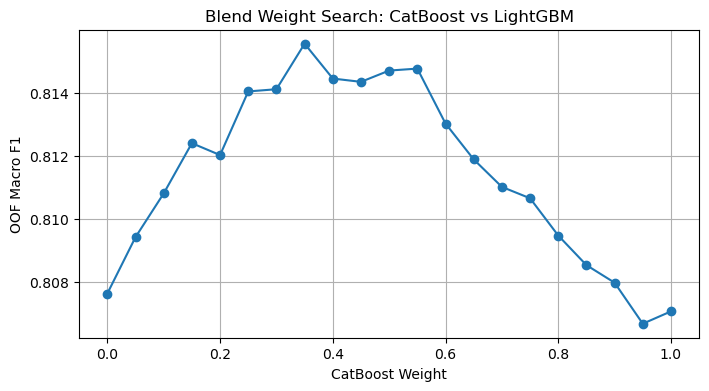

In [11]:
# Plot blend performance

plt.figure(figsize=(8, 4))
plt.plot(blend_df.sort_values("cat_weight")["cat_weight"],
         blend_df.sort_values("cat_weight")["macro_f1"],
         marker="o")
plt.xlabel("CatBoost Weight")
plt.ylabel("OOF Macro F1")
plt.title("Blend Weight Search: CatBoost vs LightGBM")
plt.grid(True)
plt.show()

In [12]:
# Set final weights

best_cat_w = 0.35
best_lgb_w = 0.65

In [13]:
# compute final blend

best_blend_oof_proba = (
    best_cat_w * cat_res["oof_proba"] +
    best_lgb_w * lgb_res["oof_proba"]
)

best_blend_oof_pred = np.argmax(best_blend_oof_proba, axis=1)

print("Best ensemble macro F1:",
      macro_f1(y_enc, best_blend_oof_pred))

Best ensemble macro F1: 0.8155514172088424
